##### Credits:
This material was adapted from https://www.tensorflow.org/tutorials

# Text classification with RNN

This notebook classifies movie reviews as *positive* or *negative* using the text of the review. This is an example of *binary*—or two-class—classification, an important and widely applicable kind of machine learning problem.

We'll use the [IMDB dataset](https://www.tensorflow.org/datasets/catalog/imdb_reviews) that contains the text of 50,000 movie reviews from the [Internet Movie Database](https://www.imdb.com/). These are split into 25,000 reviews for training and 25,000 reviews for testing. The training and testing sets are *balanced*, meaning they contain an equal number of positive and negative reviews.

This notebook uses [tf.keras](https://www.tensorflow.org/guide/keras), a high-level API to build and train models in TensorFlow. For a more advanced text classification tutorial using `tf.keras`, see the [MLCC Text Classification Guide](https://developers.google.com/machine-learning/guides/text-classification/).

## Setup

In [17]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

## Preprocess the data

### Download the IMDB dataset

The IMDB dataset comes packaged with TensorFlow in a processed format. It has already been preprocessed such that the reviews (sequences of words) have been converted to sequences of integers, where each integer represents a specific word in a dictionary.

However, in this notebook, we will use the raw text directly to demonstrate how to preprocess the raw text.

We first download the dataset and extract it to the local filesystem.

Note: the first time you run this will take a few minutes, since you are downloading ~80MB of compressed data and extracting them.

In [18]:
import requests, tarfile
from pathlib import Path

# URL to the dataset
url = 'http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'

# Download the file
response = requests.get(url, stream=True)
with open('data/aclImdb_v1.tar.gz', 'wb') as file:
    file.write(response.raw.read())

# Check if the path to the tar file exists
tar_gz_path = Path('data/aclImdb_v1.tar.gz')
if tar_gz_path.exists():
    # Create the data directory if it doesn't exist
    Path('./data').mkdir(parents=True, exist_ok=True)
    
    # Unpack the dataset
    with tarfile.open(tar_gz_path, 'r:gz') as tar:
        tar.extractall(path='./data')
else:
    print("The tar.gz file does not exist")

### Prepare the data

We extract the data from the compressed file and read the text into a list of string examples, where each example is a movie review. Originally, each movie review is given as a separate text file in a directory corresponding to its dedication as a training or text example, and its label (pos/neg). We merge all the training examples into one list, and all the test examples into another list. The first half of each list is positive examples and the second half is negative examples.

Note: this step will take a few minutes to complete.

In [19]:
import os
from pathlib import Path

# Define the path to the 'aclImdb' directory
imdb_dir = Path('./data/aclImdb')
movie_data_dir = imdb_dir / 'movie_data'

# Create 'movie_data' directory if it doesn't exist
os.makedirs(movie_data_dir, exist_ok=True)

# Process the data for train and test splits
for split in ['train', 'test']:
    # Initialize content storage for full train/test text
    full_split_content = {'pos': '', 'neg': ''}

    for sentiment in ['pos', 'neg']:
        sentiment_path = imdb_dir / split / sentiment
        all_files = sentiment_path.glob('*.txt')
        
        # Concatenate file contents
        for file_path in all_files:
            with open(file_path, 'r', encoding='utf-8') as file:
                full_split_content[sentiment] += file.read() + '\n'
    
    # Write the full content to respective files
    with open(movie_data_dir / f'full_{split}.txt', 'w', encoding='utf-8') as file:
        file.write(full_split_content['pos'])
        file.write(full_split_content['neg'])

### Load into Python

In [20]:
reviews_train = []
for line in open('./data/aclImdb/movie_data/full_train.txt', 'r'):
    reviews_train.append(line.strip())
    
reviews_test = []
for line in open('./data/aclImdb/movie_data/full_test.txt', 'r'):
    reviews_test.append(line.strip())

# Print shapes of the lists
print(f'Train data shape: {len(reviews_train)}')
print(f'Test data shape: {len(reviews_test)}')

Train data shape: 25000
Test data shape: 25000


### Clean the data and split into train/test sets

We clean the text by removing unwanted characters, and split the examples into training, validation, and test sets.

In [21]:
import re

REPLACE_NO_SPACE = re.compile("[.;:!\'?,\"()\[\]]")
REPLACE_WITH_SPACE = re.compile("(<br\s*/><br\s*/>)|(\-)|(\/)")

def preprocess_reviews(reviews):
    reviews = [REPLACE_NO_SPACE.sub("", line.lower()) for line in reviews]
    reviews = [REPLACE_WITH_SPACE.sub(" ", line) for line in reviews]
    
    return reviews

reviews_train_clean = preprocess_reviews(reviews_train)
reviews_test_clean = preprocess_reviews(reviews_test)

train_labels = np.array([1 if i < 12500 else 0 for i in range(25000)])
test_labels = np.array([1 if i < 12500 else 0 for i in range(25000)])

### Explore the data

We print a positive and a negative example. Notice the text of the reviews have been converted to lower case and punctuation characters have been removed.

In [22]:
# Inspect the first review in the training set
first_review = reviews_train_clean[0]
first_review_label = train_labels[0]

# Output the first positive review and its label
print(f"Review: {first_review}")
print(f"Review Label: {'Positive' if first_review_label else 'Negative'}")

# Output the first negative review and its label
print(f"Review: {reviews_train_clean[12500]}")
print(f"Review Label: {'Positive' if train_labels[12500] else 'Negative'}")

Review: bromwell high is a cartoon comedy it ran at the same time as some other programs about school life such as teachers my 35 years in the teaching profession lead me to believe that bromwell highs satire is much closer to reality than is teachers the scramble to survive financially the insightful students who can see right through their pathetic teachers pomp the pettiness of the whole situation all remind me of the schools i knew and their students when i saw the episode in which a student repeatedly tried to burn down the school i immediately recalled  at  high a classic line inspector im here to sack one of your teachers student welcome to bromwell high i expect that many adults of my age think that bromwell high is far fetched what a pity that it isnt
Review Label: Positive
Review: story of a man who has unnatural feelings for a pig starts out with a opening scene that is a terrific example of absurd comedy a formal orchestra audience is turned into an insane violent mob by th

## Text Processing for Deep Learning Models

In this section, we'll explore the crucial steps of text tokenization and embedding, essential for training deep learning models, particularly in natural language processing (NLP) tasks.

#### Step 1: Text Tokenization

Tokenization is the process of converting text into individual elements (tokens), which can be words, characters, or subwords. This step is the foundation for preparing text data for neural network models.

- **Tokenization**: $\text{Text} \rightarrow \text{Tokens}$
  
  Example: "Natural language processing" → ["Natural", "language", "processing"]

#### Step 2: Integer Encoding

Each token is assigned a unique integer. This transformation is necessary because neural networks cannot process raw text directly.

- **Integer Encoding**: $\text{Tokens} \rightarrow \text{Integer Tokens}$

  Example: ["Natural", "language", "processing"] → [5, 12, 19]

#### Step 3: One-Hot Encoding (Conceptual)

While not always explicitly performed in practice due to efficiency concerns, conceptually, each integer-encoded token can be represented as a one-hot encoded vector. Integer encoding inherently imposes an ordinal relationship among tokens, which is usually not meaningful in language. The model might incorrectly interpret the token encoded as 3 as having some sort of higher value or ranking compared to the token encoded as 2. In text data, such ordinal relationships are typically irrelevant and misleading. One-hot encoding removes this issue by representing each token as a vector of length $ V $, where $ V $ is the vocabulary size, with all zeros except for a '1' at the index of the token's integer encoding.

- **One-Hot Encoding**: $\text{Integer Tokens} \rightarrow \text{One-Hot Vectors}$
  
  Given a vocabulary size $ V $, a token with integer $ i $ is represented as a vector of length $ V $ with all zeros except for a '1' at the $ i $-th position.

  Example (with $ V = 10000 $): 
  - Token 'Natural' (5) → [0, 0, 0, 0, 1, 0, ..., 0] (10000-dimensional vector)

In practice, one-hot encoding is not performed explicitly because it is computationally inefficient. Instead, integer-encoded tokens are directly mapped to dense vectors of a predefined size, learned during model training. This mapping is referred to as an embedding.

#### Step 4: Embedding Layer

The embedding layer converts integer-encoded tokens into dense vectors of a fixed size. This step is crucial for capturing semantic relationships and reducing dimensionality.

- **Embedding**: $\text{Integer Tokens} \rightarrow \text{Dense Vectors}$
  
  Each integer token is mapped to a dense vector of a predefined size $ d $, learned during model training.

  Example (with $ d = 32 $): 
  - Token 'Natural' (5) → [0.24, -1.2, 0.75, ..., 0.35] (32-dimensional vector)

#### Why Embedding?

1. **Semantic Meaning**: Unlike one-hot vectors, embeddings capture semantic relationships, with similar words having similar vectors.

2. **Dimensionality Reduction**: Embeddings map high-dimensional one-hot vectors to lower-dimensional dense vectors, reducing computational complexity.

3. **Generalization**: Embeddings help the model understand different contexts and unseen words, improving its ability to generalize.

4. **Efficient Training**: Directly learning embeddings as part of the model training is computationally more efficient than dealing with sparse, high-dimensional vectors.

In summary, tokenization and embedding are critical steps in processing text data for deep learning models, enabling these models to effectively understand and work with natural language.

### Tokenization and Vectorization

As strings cannot directly be used with a neural network, we must first convert the strings into a numerical representation. To do so, we must first split the strings into words (or tokens). We then build a vocabulary of all the words in the texts and map each word to an integer. 

We set the vocabulary size to 10000, meaning we will only use the top 10000 words in the vocabulary and map the rest to the integer 0. The top 10000 words are chosen based on their frequency in the training set.

Finally, we convert each text into a sequence of integers corresponding to the tokens in the text. We pad each sequence to the same length as the longest sequence, which is 500 in this case.

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Instantiate the tokenizer
num_words = 10000  # Vocabulary size
maxlen = 500       # Maximum length of review
tokenizer = Tokenizer(num_words=num_words, oov_token='<OOV>')  # Out of Vocabulary will be represented by <OOV>
tokenizer.fit_on_texts(reviews_train_clean)

# Convert the texts to sequences
train_sequences = tokenizer.texts_to_sequences(reviews_train_clean)
test_sequences = tokenizer.texts_to_sequences(reviews_test_clean)

# Pad the sequences with zeros at the end to have the same length
train_data = pad_sequences(train_sequences, maxlen=maxlen, padding='post')
test_data = pad_sequences(test_sequences, maxlen=maxlen, padding='post')

We print the first tokenized example. Notice that all the words are mapped to integers. The integers represent the index of the word in the vocabulary.

In [24]:
# Print the first tokenized review
print(f"Tokenized review: {train_data[0]}")

Tokenized review: [   1  304    7    4 1068  209    9 2151   31    2  168   54   14   46
   81 5647   42  392  110  137   14 4972   58 4480  146    8    2 4973
 5899  483   69    6  259   12    1    1 1999    7   73 2415    6  628
   71    7 4972    2    1    6 2017    1    2 5824 1461   36   68   64
  204  139   65 1226 4972    1    2    1    5    2  221  894   30 3006
   69    5    2 4786   10  695    3   65 1461   51   10  215    2  389
    8   60    4 1462 3697  796    6 3535  178    2  392   10 1229    1
   31  304    4  351  341 2982  142  129    6 7760   28    5  125 4972
 1462 2366    6    1  304   10  531   12  106 1479    5   58  553  102
   12    1  304    7  226 4169   48    4 2228   12    9  213    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    

We can also reverse the mapping and print the first review. Notice that some words have been replated by the token `<OOV>` (out of vocabulary) because they are not in the vocabulary.

In [25]:
# Decode the first tokenized review
print(f"Decoded review: {tokenizer.sequences_to_texts([train_data[0]])}")

Decoded review: ['<OOV> high is a cartoon comedy it ran at the same time as some other programs about school life such as teachers my 35 years in the teaching profession lead me to believe that <OOV> <OOV> satire is much closer to reality than is teachers the <OOV> to survive <OOV> the insightful students who can see right through their pathetic teachers <OOV> the <OOV> of the whole situation all remind me of the schools i knew and their students when i saw the episode in which a student repeatedly tried to burn down the school i immediately <OOV> at high a classic line inspector im here to sack one of your teachers student welcome to <OOV> high i expect that many adults of my age think that <OOV> high is far fetched what a pity that it isnt <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <O

## Build the model

The neural network is created by stacking layers—this requires two main architectural decisions:

* How many layers to use in the model?
* How many *hidden units* to use for each layer?

In this example, the input data consists of an array of word-indices. The labels to predict are either 0 or 1. 

Build a `tf.keras.Sequential` model and start with an embedding layer. An embedding layer stores one vector per word. When called, it converts the sequences of word indices to sequences of vectors. These vectors are trainable. After training (on enough data), words with similar meanings often have similar vectors.

This index-lookup is much more efficient than the equivalent operation of passing a one-hot encoded vector through a `tf.keras.layers.Dense` layer.

A recurrent neural network (RNN) processes sequence input by iterating through the elements. RNNs pass the outputs from one timestep to their input—and then to the next.

The `tf.keras.layers.Bidirectional` wrapper can also be used with an RNN layer. This propagates the input forward and backwards through the RNN layer and then concatenates the output. This helps the RNN to learn long range dependencies.

<img src="images/bidirectional-lstm.png" alt="bidirectional lstm" width="400"/>

In [26]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=num_words, input_length=maxlen, output_dim=32),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=32)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 500, 32)           320000    
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                16640     
 onal)                                                           
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 338753 (1.29 MB)
Trainable params: 338753 (1.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The layers are stacked sequentially to build the classifier:

1. The first layer is an `Embedding` layer. This layer takes the integer-encoded vocabulary and looks up the embedding vector for each word-index. These vectors are learned as the model trains. The vectors add a dimension to the output array. The resulting dimensions are: `(batch, sequence, embedding)`.
2. Next, a `Bidirectional LSTM` layer. That means that word sequences can be processed in both directions. This layer produces a 32-dimensional output.
3. This fixed-length output vector is piped through a fully-connected (`Dense`) layer with 32 hidden units.
4. The last layer is densely connected with a single output node. Using the `sigmoid` activation function, this value is a float between 0 and 1, representing a probability, or confidence level. For numerical stability, use the `linear` activation function that represents the logits.

### Hidden units

The above model has three intermediate or "hidden" layers, between the input and output. The number of outputs (units, nodes, or neurons) is the dimension of the representational space for the layer. In other words, the amount of freedom the network is allowed when learning an internal representation.

If a model has more hidden units (a higher-dimensional representation space), and/or more layers, then the network can learn more complex representations. However, it makes the network more computationally expensive and may lead to learning unwanted patterns—patterns that improve performance on training data but not on the test data. This is called *overfitting*, and we'll explore it later.

### Loss function and optimizer

A model needs a loss function and an optimizer for training. Since this is a binary classification problem and the model outputs a probability (a single-unit layer with a sigmoid activation), we'll use the `binary_crossentropy` loss function.

This isn't the only choice for a loss function, you could, for instance, choose `mean_squared_error`. But, generally, `binary_crossentropy` is better for dealing with probabilities—it measures the "distance" between probability distributions, or in our case, between the ground-truth distribution and the predictions.

Note: When working with multiclass problems and on-hot-encoding, a `softmax` output activation function, and `categorical_crossentropy` is preferable.

Now, configure the model to use an optimizer and a loss function:

In [27]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

## Train the model

Train the model by passing the `Dataset` object to the model's fit function. Set the number of epochs.

In [28]:
history = model.fit(train_data, train_labels, epochs=5, batch_size=32, validation_split=0.2, shuffle=True)

Epoch 1/5


625/625 [==============================] - 83s 128ms/step - loss: 0.6418 - accuracy: 0.6253 - val_loss: 0.8804 - val_accuracy: 0.0550
Epoch 2/5
625/625 [==============================] - 80s 129ms/step - loss: 0.4630 - accuracy: 0.7988 - val_loss: 0.8888 - val_accuracy: 0.6460
Epoch 3/5
625/625 [==============================] - 81s 129ms/step - loss: 0.3334 - accuracy: 0.8740 - val_loss: 0.6339 - val_accuracy: 0.7698
Epoch 4/5
625/625 [==============================] - 81s 129ms/step - loss: 0.2688 - accuracy: 0.9001 - val_loss: 0.3441 - val_accuracy: 0.8948
Epoch 5/5
625/625 [==============================] - 81s 129ms/step - loss: 0.2267 - accuracy: 0.9178 - val_loss: 0.4891 - val_accuracy: 0.8236


## Evaluate the model

And let's see how the model performs. Two values will be returned. Loss (a number which represents our error, lower values are better), and accuracy.

In [29]:
test_loss, test_acc = model.evaluate(test_data, test_labels)

print('Test Loss: {}'.format(test_loss))
print('Test Accuracy: {}'.format(test_acc))

  2/782 [..............................] - ETA: 39s - loss: 0.1902 - accuracy: 0.9062 

782/782 [==============================] - 39s 49ms/step - loss: 0.3374 - accuracy: 0.8690
Test Loss: 0.3374490737915039
Test Accuracy: 0.8689600229263306


This fairly naive approach achieves an accuracy of about 87%. With more advanced approaches, the model should get closer to 95%.

## Create a graph of accuracy and loss over time

`model.fit()` returns a `History` object that contains a dictionary with everything that happened during training:

In [30]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

There are four entries: one for each monitored metric during training and validation. We can use these to plot the training and validation loss for comparison, as well as the training and validation accuracy:

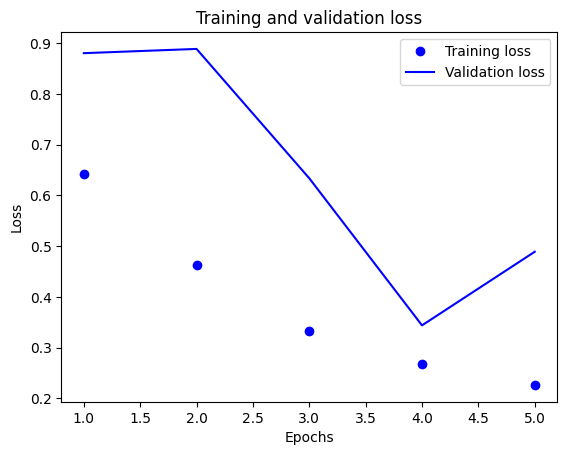

In [31]:
import matplotlib.pyplot as plt

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

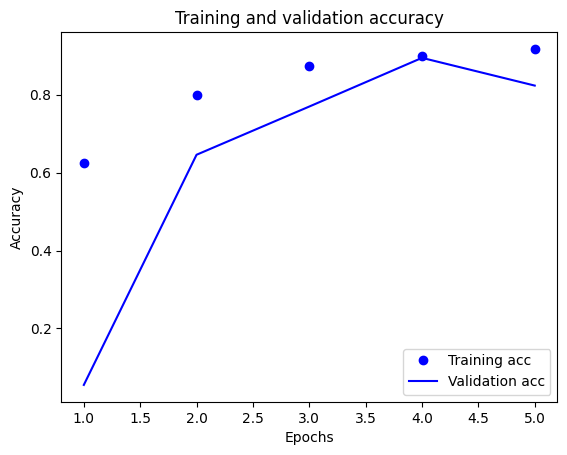

In [32]:
plt.clf()   # clear figure

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In this plot, the dots represent the training loss and accuracy, and the solid lines are the validation loss and accuracy.

Notice the training loss *decreases* with each epoch and the training accuracy *increases* with each epoch. This is expected when using a gradient descent optimization—it should minimize the desired quantity on every iteration.

This isn't the case for the validation loss and accuracy—they seem to peak after about twenty epochs. This is an example of overfitting: the model performs better on the training data than it does on data it has never seen before. After this point, the model over-optimizes and learns representations *specific* to the training data that do not *generalize* to test data.

For this particular case, we could prevent overfitting by simply stopping the training after twenty or so epochs. Later, you'll see how to do this automatically with a callback.

Check out other existing recurrent layers such as [GRU layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU).

If you're interestied in building custom RNNs, see the [Keras RNN Guide](https://www.tensorflow.org/guide/keras/rnn).
